Compiling model...
'compile' took 1.764900 s

Training model...

Step      Train loss                        Test loss                         Test metric   
0         [6.95e-02, 1.00e+00, 5.53e+00]    [6.62e-02, 1.00e+00, 5.53e+00]    [1.02e+00]    


/home/hridoy/miniconda3/envs/torch-env/lib/python3.10/site-packages/torch/autograd/graph.py:823: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:180.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


1000      [1.11e+00, 8.98e-01, 8.89e-01]    [1.10e+00, 8.98e-01, 8.89e-01]    [9.37e-01]    
2000      [5.27e-04, 9.13e-07, 2.08e-06]    [1.02e-03, 9.13e-07, 2.08e-06]    [9.32e-04]    
3000      [5.86e-05, 3.17e-09, 1.85e-08]    [2.01e-04, 3.18e-09, 1.88e-08]    [1.18e-04]    
4000      [4.35e-05, 2.42e-09, 8.42e-08]    [1.45e-04, 2.41e-09, 8.42e-08]    [1.27e-04]    
5000      [3.18e-05, 2.99e-10, 1.42e-08]    [1.11e-04, 2.95e-10, 1.42e-08]    [9.38e-05]    
6000      [2.34e-05, 5.29e-10, 3.00e-08]    [8.37e-05, 5.24e-10, 2.99e-08]    [5.62e-05]    
7000      [2.73e-04, 1.92e-06, 7.22e-05]    [2.28e-04, 1.92e-06, 7.22e-05]    [1.44e-03]    
8000      [3.17e-05, 1.86e-06, 1.13e-06]    [5.47e-05, 1.86e-06, 1.13e-06]    [1.39e-03]    
9000      [1.00e-05, 3.33e-10, 5.91e-10]    [3.03e-05, 3.33e-10, 6.03e-10]    [8.80e-05]    
10000     [7.98e-06, 1.48e-10, 8.05e-10]    [2.32e-05, 1.42e-10, 7.91e-10]    [7.38e-05]    

Best model at step 10000:
  train loss: 7.98e-06
  test loss: 2.32e-0

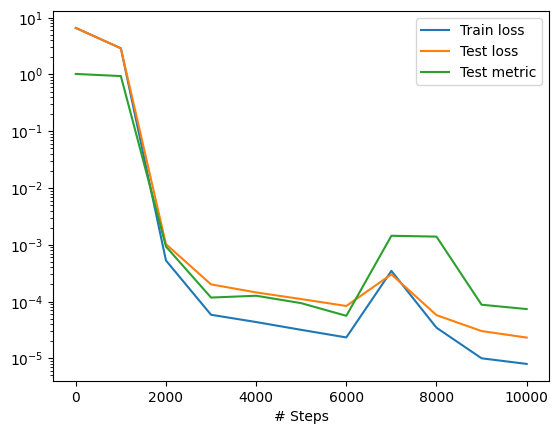

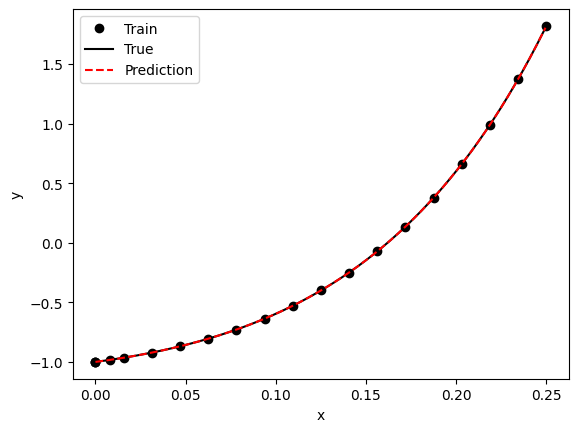

In [2]:
import deepxde as dde
import numpy as np

def ode(t, y):
    dy_dt = dde.grad.jacobian(y, t)
    dy2_dt2 = dde.grad.hessian(y, t)
    return dy2_dt2 - 10 * dy_dt + 9 * y - 5 * t


def func(t):
    return 50 / 81 + t * 5 / 9 - 2 * np.exp(t) + (31 / 81) * np.exp(9 * t)


geom = dde.geometry.TimeDomain(0, 0.25)


def boundary_l(t, on_initial):
    return on_initial and dde.utils.isclose(t[0], 0)


def bc_func1(inputs, outputs, X):
    return outputs + 1


def bc_func2(inputs, outputs, X):
    return dde.grad.jacobian(outputs, inputs, i=0, j=None) - 2


ic1 = dde.icbc.IC(geom, lambda x: -1, lambda _, on_initial: on_initial)
ic2 = dde.icbc.OperatorBC(geom, bc_func2, boundary_l)

data = dde.data.TimePDE(geom, ode, [ic1, ic2], 16, 2, solution=func, num_test=500)
layer_size = [1] + [50] * 3 + [1]
activation = "tanh"
initializer = "Glorot uniform"
net = dde.nn.FNN(layer_size, activation, initializer)

model = dde.Model(data, net)
model.compile("adam", lr=0.001, metrics=["l2 relative error"], loss_weights=[0.01, 1, 1])
losshistory, train_state = model.train(iterations=10000)

dde.saveplot(losshistory, train_state, issave=False, isplot=True)